<style>
    .input_area, .output_area, pre, code {
        white-space: pre-wrap !important;
        word-wrap: break-word !important;
    }
</style>

In [7]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns 

import sqlite3 as db

import sys
sys.path.append("../src")
from trainTestSplit import get_class_splits

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, average_precision_score, recall_score, classification_report, f1_score, make_scorer, ConfusionMatrixDisplay
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from xgboost import XGBClassifier

from ydata_profiling import ProfileReport

Query from curated master dataset and create a dataframe

In [8]:
# Load data
conn = db.connect("../data/charlotte_housing.db")

master_df = pd.read_sql_query("SELECT * FROM master", conn)

conn.close()

print(f"Data loaded successfully. Master dataset shape:, {master_df.shape[0]} records, {master_df.shape[1]} features.")
display(master_df.head())


Data loaded successfully. Master dataset shape:, 458 records, 23 features.


,NPA,household_income,home_ownership,rental_houses,food_nutrition,employment,housing_age,code_violations,foreclosures,new_constructions,...,race_white,race_hispanic,race_asian,race_other,transit_proximity,financial_proximity,grocery_proximity,housing_cost_burden,displacement_risk,crime_total
0,2,-0.407371,-0.685002,-0.163924,0.240595,0.088074,1.908974,0.229973,-0.351833,-0.303270,...,0.571876,-0.392703,-0.618768,1.897747,0.242736,-0.292939,0.376054,0.278606,0,0.581649
1,3,0.436290,-0.677445,1.314855,-0.957022,0.482288,2.089046,0.106927,-0.351833,1.549196,...,1.265442,-0.812366,-0.224057,-0.070897,9.043236,10.992720,9.194680,0.284134,0,3.480599
2,4,3.586770,1.531572,-0.911621,-1.108914,0.555413,0.408373,-0.631352,-0.351833,-0.284652,...,1.606091,-1.007781,-0.260578,-1.391047,-0.560484,-0.551553,-0.673864,0.151362,0,-0.618596
3,5,-0.868820,-1.245985,-0.172231,1.777049,-1.885547,1.368758,0.845205,-0.351833,0.134247,...,-1.197404,-0.254952,-0.697429,-0.009136,-0.578973,-0.546764,-0.750563,0.313884,1,-0.264850
4,6,-1.107639,-0.946507,1.937935,1.169478,0.914241,1.728902,1.337391,5.110524,-0.154328,...,-1.057031,-0.429544,-0.791542,-0.541828,-0.078758,0.062656,-0.143792,0.633077,1,1.814352


Train/Test Split

In [9]:
X_train, X_test, y_train, y_test = get_class_splits(master_df)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")
print(f"\nClass distribution in training set:")
print(y_train.value_counts())
print(f"\nClass distribution in testing set:")
print(y_test.value_counts())


Training set: 343 rows
Testing set: 115 rows

Class distribution in training set:
displacement_risk
0    256
1     87
Name: count, dtype: int64

Class distribution in testing set:
displacement_risk
0    86
1    29
Name: count, dtype: int64


Logistic Regression 


 ------------ Cross-Validation Results (Logistic Regression) ------------
Mean F1 Score: 0.733666632730728
Mean Recall Score: 0.8398692810457515
Mean Average Precision Score: 0.5897628413175593

 ------------ Logistic Regression Results at Threshold 0.3 ------------
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        86
           1       0.68      0.86      0.76        29

    accuracy                           0.86       115
   macro avg       0.81      0.86      0.83       115
weighted avg       0.88      0.86      0.87       115

F1 Score: 0.7575757575757576
Recall Score 0.8620689655172413
Average Precision Score: 0.8680435551330713

 ------------ Logistic Regression Results at Threshold 0.4 ------------
              precision    recall  f1-score   support

           0       0.94      0.87      0.90        86
           1       0.69      0.83      0.75        29

    accuracy                           0.86       115
   macro 

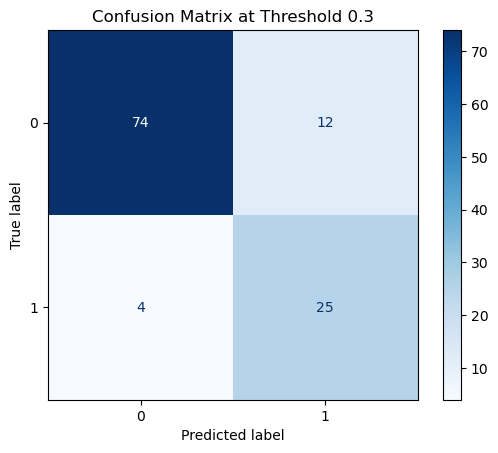


 ------------ Feature Importance (Logistic Regression Model) ------------
                Feature  Coefficient  Abs_Coefficient
0      household_income    -1.942876         1.942876
16    transit_proximity     1.790890         1.790890
3        food_nutrition     1.276453         1.276453
9       housing_density    -1.202367         1.202367
5           housing_age     0.861277         0.861277
14           race_asian    -0.732759         0.732759
13        race_hispanic     0.673595         0.673595
20          crime_total    -0.607103         0.607103
11           race_black     0.547031         0.547031
6       code_violations     0.509001         0.509001
17  financial_proximity    -0.396264         0.396264
1        home_ownership     0.351638         0.351638
7          foreclosures    -0.283381         0.283381
19  housing_cost_burden     0.244362         0.244362
2         rental_houses     0.183410         0.183410
4            employment    -0.171023         0.171023
12     

In [13]:
#defining target and features
y = master_df['displacement_risk']
X = master_df.drop(columns=['displacement_risk', 'NPA']) #dropping id and target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


log_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight= 'balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1': make_scorer(f1_score),
    'recall': make_scorer(recall_score),
    'average_precision': make_scorer(average_precision_score)
}

cv_results = cross_validate(
    log_pipeline, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False
)

print("\n ------------ Cross-Validation Results (Logistic Regression) ------------")
print("Mean F1 Score:", cv_results['test_f1'].mean())
print("Mean Recall Score:", cv_results['test_recall'].mean())
print("Mean Average Precision Score:", cv_results['test_average_precision'].mean())

#training model
log_pipeline.fit(X_train, y_train)


#getting probabilities
y_prob = log_pipeline.predict_proba(X_test)[:, 1]

#evaluating model at different thresholds
thresholds = [0.3, 0.4, 0.5]
for t in thresholds:
    y_pred_thresh = (y_prob >= t).astype(int)
    print(f"\n ------------ Logistic Regression Results at Threshold {t} ------------")
    print(classification_report(y_test, y_pred_thresh))
    print("F1 Score:", f1_score(y_test, y_pred_thresh))
    print("Recall Score", recall_score(y_test, y_pred_thresh))
    print("Average Precision Score:", average_precision_score(y_test, y_prob))

#confusion matrix(for threshold of 0.3)
main_threshold = 0.3
y_pred_best = (y_prob >= main_threshold).astype(int)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, cmap="Blues")
plt.title(f"Confusion Matrix at Threshold {main_threshold}")
plt.show()

#extracting the coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_pipeline.named_steps['model'].coef_[0]
})

#sorting by absolute value of coefficients
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients_sorted = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\n ------------ Feature Importance (Logistic Regression Model) ------------")
print(coefficients_sorted)



Logistic Regression Model #2 


 ------ Cross-Validation Results (Logistic Regression with Selected Features) ------
Mean F1 Score: 0.7013497097218027
Mean Recall Score: 0.8745098039215687
Mean Average Precision Score: 0.5463982661481951
Confusion Matrix:


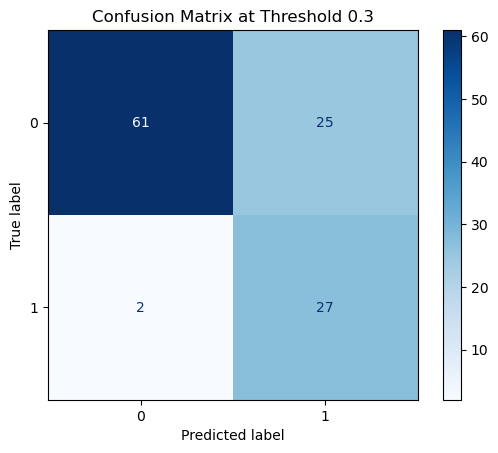


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.71      0.82        86
           1       0.52      0.93      0.67        29

    accuracy                           0.77       115
   macro avg       0.74      0.82      0.74       115
weighted avg       0.86      0.77      0.78       115

F1 Score: 0.6666666666666666
Recall Score 0.9310344827586207
Average Precision Score: 0.7870283578946631

 ------ Feature Importance (Logistic Regression Model with Selected Features) ------
            Feature  Coefficient  Abs_Coefficient
0  household_income    -3.598307         3.598307
2     rental_houses     0.332080         0.332080
4       crime_total     0.129574         0.129574
1    home_ownership    -0.101744         0.101744
3      foreclosures     0.096898         0.096898


In [16]:
features = [
    'household_income',
    'home_ownership',
    'rental_houses',
    'foreclosures',
    'crime_total'
]

x = master_df[features]
y = master_df['displacement_risk']  

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

log_model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight= 'balanced'))
])

#cross-validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'f1': make_scorer(f1_score),
    'recall': make_scorer(recall_score),
    'average_precision': make_scorer(average_precision_score)
}

cv_results = cross_validate(
    log_model, X_train, y_train, cv=cv, scoring=scoring)

print("\n ------ Cross-Validation Results (Logistic Regression with Selected Features) ------")
print("Mean F1 Score:", cv_results['test_f1'].mean())
print("Mean Recall Score:", cv_results['test_recall'].mean())
print("Mean Average Precision Score:", cv_results['test_average_precision'].mean())


log_model.fit(X_train, y_train)

y_prob = log_model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title(f"Confusion Matrix at Threshold {threshold}")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))
print("Recall Score", recall_score(y_test, y_pred))
print("Average Precision Score:", average_precision_score(y_test, y_prob))

#coefficients for the selected features
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_model.named_steps['model'].coef_[0]
})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients_sorted = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\n ------ Feature Importance (Logistic Regression Model with Selected Features) ------")
print(coefficients_sorted)


Logistic Regression Model #3 with selected features


 ------ Cross-Validation Results (Logistic Regression with Selected Features) ------
Mean F1 Score: 0.770343438250415
Mean Recall Score: 0.8751633986928106
Mean Average Precision Score: 0.638867536585399
Confusion Matrix:


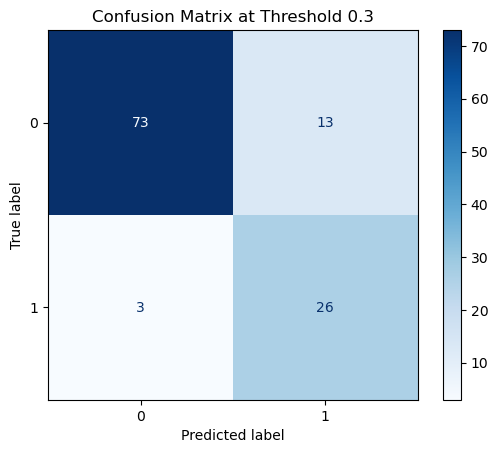


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90        86
           1       0.67      0.90      0.76        29

    accuracy                           0.86       115
   macro avg       0.81      0.87      0.83       115
weighted avg       0.89      0.86      0.87       115

F1 Score: 0.7647058823529411
Recall Score 0.896551724137931
Average Precision Score: 0.9087749332491849

 ------ Feature Importance (Logistic Regression Model with Selected Features) ------
             Feature  Coefficient  Abs_Coefficient
0   household_income    -2.397766         2.397766
2     food_nutrition     1.802186         1.802186
3    housing_density    -1.372807         1.372807
1  transit_proximity     1.256653         1.256653
4        housing_age     0.514759         0.514759


In [18]:
features = [
    "household_income",
    "transit_proximity",
    "food_nutrition",
    "housing_density",
    "housing_age"
]

x = master_df[features]
y = master_df['displacement_risk']  

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

log_model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight= 'balanced'))
])

#cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'f1': make_scorer(f1_score),
    'recall': make_scorer(recall_score),
    'average_precision': make_scorer(average_precision_score)
}
cv_results = cross_validate(
    log_model, X_train, y_train, cv=cv, scoring=scoring)

print("\n ------ Cross-Validation Results (Logistic Regression with Selected Features) ------")
print("Mean F1 Score:", cv_results['test_f1'].mean())
print("Mean Recall Score:", cv_results['test_recall'].mean())
print("Mean Average Precision Score:", cv_results['test_average_precision'].mean())

log_model.fit(X_train, y_train)

y_prob = log_model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)




print("Confusion Matrix:")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title(f"Confusion Matrix at Threshold {threshold}")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))
print("Recall Score", recall_score(y_test, y_pred))
print("Average Precision Score:", average_precision_score(y_test, y_prob))

#coefficients for the selected features
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_model.named_steps['model'].coef_[0]
})
coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients_sorted = coefficients.sort_values(by='Abs_Coefficient', ascending=False)

print("\n ------ Feature Importance (Logistic Regression Model with Selected Features) ------")
print(coefficients_sorted)
